In [1]:
from torch_geometric.data import Data

In [2]:
import os
import glob
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import numpy as np

class ViolenceDataset(Dataset):
    def __init__(self, root_dir, clip_len=60, transform=None):
        """
        Args:
            root_dir (str): dataset root folder with 'violent/' and 'non_violent/' subfolders
            clip_len (int): number of frames to sample per clip
            transform: optional callable to augment or normalize features
        """
        self.samples = []
        self.labels = []
        self.clip_len = clip_len
        self.transform = transform

        classes = {"non_violent": 0, "violent": 1}

        for class_name, label in classes.items():
            folder = os.path.join(root_dir, class_name, 'cam1')
            for npy_file in glob.glob(os.path.join(folder, "*.npy")):
                self.samples.append(npy_file)
                self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Load features (T, P, V, F)
        clip_path = self.samples[idx]
        clip = np.load(clip_path)  # shape: (T, P, V, F)
        label = self.labels[idx]

        T = clip.shape[0]

        # --- Uniform temporal sampling ---
        if T >= self.clip_len:
            indices = np.linspace(0, T-1, self.clip_len).astype(int)
            clip = clip[indices]
        else:
            pad = np.zeros((self.clip_len - T, *clip.shape[1:]), dtype=np.float32)
            clip = np.concatenate([clip, pad], axis=0)

        if self.transform:
            clip = self.transform(clip)

        clip = torch.tensor(clip, dtype=torch.float32)  # (T, P, V, F)
        clip = clip.permute(3, 0, 2, 1)  # (F, T, V, P)

        label = torch.tensor(label, dtype=torch.long)

        return clip, label, clip_path


In [3]:
data = ViolenceDataset('transformed_data')
element = DataLoader(data, batch_size=1, shuffle=True, collate_fn=lambda x: x)
for i, batch in enumerate(element):
    print(i, type(batch), len(batch))
    print("Clip shape:", batch[0][0].shape)
    print("Label:", batch[0][1])
    print("path:", batch[0][2])
    break

0 <class 'list'> 1
Clip shape: torch.Size([5, 60, 17, 6])
Label: tensor(0)
path: transformed_data/non_violent/cam1/38.npy


In [4]:
# COCO skeleton edges (17 joints, MoveNet convention)
COCO_EDGES = [
    (0, 1), (0, 2),
    (1, 3), (2, 4),
    (0, 5), (0, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 12)
]

In [5]:
def frame_to_graph(frame, edges=COCO_EDGES):
    """
    frame: (P, V, F) tensor (people, joints, features)
    returns: list of Data objects (one graph per person, empty ones skipped)
    """
    people_graphs = []
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    for person in frame:  # (V, F)
        # Skip empty person (all features == 0)
        if torch.all(person == 0):
            continue

        x = person  # node features (17, F)
        data = Data(x=x, edge_index=edge_index)
        people_graphs.append(data)

    return people_graphs


def clip_to_graphs(clip):
    """
    clip: (F, T, V, P)
    returns: list of [graphs per frame]
             len = T, each element = list of Data objects
    """
    graphs_per_frame = []
    F, T, V, P = clip.shape

    for t in range(T):
        frame = clip[:, t, :, :]        # (F, V, P)
        frame = frame.permute(2, 1, 0)  # -> (P, V, F)
        graphs = frame_to_graph(frame)
        graphs_per_frame.append(graphs)

    return graphs_per_frame


In [6]:
class ViolenceGraphDataset(Dataset):
    def __init__(self, base_dataset):
        """
        Args:
            base_dataset: an instance of ViolenceDataset
        """
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        clip, label, path = self.base[idx]   # clip: (F, T, V, P)
        graph_seq = clip_to_graphs(clip)  # list of [graphs per frame]
        return graph_seq, label, path

In [11]:
base_dataset = ViolenceDataset(root_dir="transformed_data", clip_len=60)
graph_dataset = ViolenceGraphDataset(base_dataset)

In [12]:
graph_seq, label, path = graph_dataset[0]
print("Frames:", len(graph_seq))          # T frames
print("Graphs in first frame:", graph_seq[0])  # list of Data per person
print("Label:", label)


Frames: 60
Graphs in first frame: [Data(x=[17, 5], edge_index=[2, 17]), Data(x=[17, 5], edge_index=[2, 17]), Data(x=[17, 5], edge_index=[2, 17])]
Label: tensor(0)


transformed_data/non_violent/cam1/32.npy


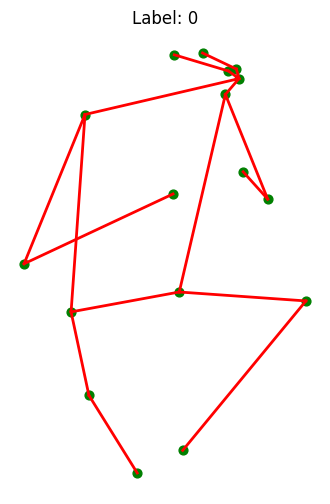

In [14]:
import matplotlib.pyplot as plt
def plot_graph(graph, title=None):
    """
    graph: torch_geometric.data.Data object
    """
    x = graph.x.numpy()   # shape: (17, 5) -> use first two columns (x, y)
    edge_index = graph.edge_index.numpy()

    # Plot joints
    plt.figure(figsize=(4, 6))
    plt.scatter(x[:, 0], -x[:, 1], c='green', s=40)  # invert y for visualization

    # Plot edges
    for i, j in edge_index.T:
        plt.plot([x[i, 0], x[j, 0]], [-x[i, 1], -x[j, 1]], 'r-', lw=2)

    plt.title(title if title else "Skeleton Graph")
    plt.axis('off')
    plt.show()

# Example: visualize first person in first frame
graph_seq, label, path = graph_dataset[0]
print(path)
plot_graph(graph_seq[39][0], title=f"Label: {label.item()}")

In [27]:
graph_seq[0][0]

Data(x=[17, 5], edge_index=[2, 17])

In [29]:
graph_seq[1][0].edge_index

tensor([[ 0,  0,  1,  2,  0,  0,  5,  7,  6,  8,  5,  6, 11, 13, 12, 14, 11],
        [ 1,  2,  3,  4,  5,  6,  7,  9,  8, 10, 11, 12, 13, 15, 14, 16, 12]])

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class STGCN(nn.Module):
    def __init__(self, in_channels=5, hidden_channels=64, num_classes=2, dropout=0.3):
        super(STGCN, self).__init__()
        self.gcn1 = GCNConv(in_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)
        self.lstm = nn.LSTM(hidden_channels, hidden_channels, batch_first=True)
        self.fc = nn.Linear(hidden_channels, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_channels)

    def forward(self, batch_graph_seqs):
        """
        batch_graph_seqs: list of [graph_seq] (one per video)
        """
        batch_embs = []

        for graph_seq in batch_graph_seqs:  # loop over videos
            frame_embs = []

            for graphs in graph_seq:  # loop over frames
                if len(graphs) == 0:
                    frame_embs.append(torch.zeros(1, self.gcn1.out_channels, device=self.fc.weight.device))
                    continue

                person_embs = []
                for g in graphs:
                    x = g.x.to(self.fc.weight.device)
                    edge_index = g.edge_index.to(self.fc.weight.device)
                    h = F.relu(self.gcn1(x, edge_index))
                    h = F.relu(self.gcn2(h, edge_index))
                    h = global_mean_pool(h, torch.zeros(h.size(0), dtype=torch.long, device=h.device))
                    person_embs.append(h)

                frame_emb = torch.mean(torch.stack(person_embs), dim=0)
                frame_embs.append(frame_emb)

            frame_embs = torch.cat(frame_embs, dim=0).unsqueeze(0)  # (1, T, C)
            frame_embs = self.layer_norm(frame_embs)
            _, (h_n, _) = self.lstm(frame_embs)
            video_emb = h_n[-1]
            batch_embs.append(video_emb)

        batch_embs = torch.cat(batch_embs, dim=0)
        out = self.fc(self.dropout(batch_embs))
        return out


In [31]:
def collate_fn(batch):
    """
    Custom collate function for graph sequences.
    Args:
        batch: list of (graph_seq, label, path)
    Returns:
        graph_seqs: list of graph sequences (each a list of frames with graphs)
        labels: torch.tensor of labels
        paths: list of paths
    """
    graph_seqs, labels, paths = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.long)
    return graph_seqs, labels, paths


In [32]:
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# split dataset
base_dataset = ViolenceDataset(root_dir="transformed_data", clip_len=60)
graph_dataset = ViolenceGraphDataset(base_dataset)

train_idx, val_idx = train_test_split(list(range(len(graph_dataset))), test_size=0.2, random_state=42)
train_subset = torch.utils.data.Subset(graph_dataset, train_idx)
val_subset = torch.utils.data.Subset(graph_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_subset, batch_size=4, shuffle=False, collate_fn=collate_fn)

# model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STGCN(in_channels=5, hidden_channels=64, num_classes=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(10):
    model.train()
    total_loss = 0
    for graph_seqs, labels, _ in tqdm(train_loader):
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(graph_seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f}")

    # validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for graph_seqs, labels, _ in val_loader:
            labels = labels.to(device)
            outputs = model(graph_seqs)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Val Acc: {acc:.3f}")

100%|██████████| 35/35 [00:37<00:00,  1.08s/it]


Epoch 1 | Train Loss: 0.6303
Val Acc: 0.543


100%|██████████| 35/35 [00:38<00:00,  1.09s/it]


Epoch 2 | Train Loss: 0.6207
Val Acc: 0.543


100%|██████████| 35/35 [00:38<00:00,  1.10s/it]


...

Epoch 8 | Train Loss: 0.5764
Val Acc: 0.543


100%|██████████| 35/35 [00:36<00:00,  1.04s/it]


Epoch 9 | Train Loss: 0.5712
Val Acc: 0.543


100%|██████████| 35/35 [00:38<00:00,  1.09s/it]


Epoch 10 | Train Loss: 0.5381
Val Acc: 0.600


In [35]:
model

STGCN(
  (gcn1): GCNConv(5, 64)
  (gcn2): GCNConv(64, 64)
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

In [ ]:
torch.save(model.state_dict(), "best.pt")